In [63]:
import pandas as pd
import numpy as np
import re  
import nltk  
import spacy  
import string 

trdf = pd.read_csv('train.csv', header='infer')
print(trdf.head(3))
trdf.info()


   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   

   target  
0       1  
1       1  
2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [64]:
# # --------------------------------------------
# 1. CASE CONVERSION
# --------------------------------------------
trdf['lowered_text'] = trdf['text'].str.lower()
print(trdf['lowered_text'].head(3))


0    our deeds are the reason of this #earthquake m...
1               forest fire near la ronge sask. canada
2    all residents asked to 'shelter in place' are ...
Name: lowered_text, dtype: object


In [65]:
# --------------------------------------------
# Step 2: Removing Punctuation from Text
# --------------------------------------------

# Get all punctuation characters
punctuation = string.punctuation
print(type(punctuation), punctuation) 

# Create a translation map to remove punctuation characters
mapping = str.maketrans("", "", punctuation)
print(type(mapping), mapping) 

# Apply translation to remove punctuation from text
print(trdf['lowered_text'].head(10))
trdf['lowered_text'] = trdf["lowered_text"].str.translate(mapping)
print(trdf['lowered_text'].head(10))

# Alternative function-based implementation
# def remove_punctuation(in_str):
#     return in_str.translate(mapping)

# Example usage:
# trdf['lowered_text'] = trdf["lowered_text"].apply(remove_punctuation)

<class 'str'> !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
<class 'dict'> {33: None, 34: None, 35: None, 36: None, 37: None, 38: None, 39: None, 40: None, 41: None, 42: None, 43: None, 44: None, 45: None, 46: None, 47: None, 58: None, 59: None, 60: None, 61: None, 62: None, 63: None, 64: None, 91: None, 92: None, 93: None, 94: None, 95: None, 96: None, 123: None, 124: None, 125: None, 126: None}
0    our deeds are the reason of this #earthquake m...
1               forest fire near la ronge sask. canada
2    all residents asked to 'shelter in place' are ...
3    13,000 people receive #wildfires evacuation or...
4    just got sent this photo from ruby #alaska as ...
5    #rockyfire update => california hwy. 20 closed...
6    #flood #disaster heavy rain causes flash flood...
7    i'm on top of the hill and i can see a fire in...
8    there's an emergency evacuation happening now ...
9    i'm afraid that the tornado is coming to our a...
Name: lowered_text, dtype: object
0    our deeds are the reason

In [66]:
# --------------------------------------------
# Step 3: Removing Stopwords
# --------------------------------------------

from nltk.corpus import stopwords

# Load standard English stopwords
stopwords_eng = stopwords.words('english')
print(type(stopwords_eng), len(stopwords_eng)) 
print(stopwords_eng)

print(trdf["lowered_text"].head(10))

# Function to remove stopwords from a string
def remove_stopwords(in_str):
    return " ".join([word for word in in_str.split() if word not in stopwords_eng])

trdf['lowered_text_stop_removed'] = trdf["lowered_text"].apply(remove_stopwords)
print(trdf["lowered_text_stop_removed"].head(10))


<class 'list'> 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'sh

In [67]:
# --------------------------------------------
# Step 4: Identifying and Removing Frequent Words
# --------------------------------------------

from collections import Counter

# Count frequency of each word in the preprocessed text
counter = Counter()
for text in trdf["lowered_text_stop_removed"]:
    for word in text.split():
        counter[word] += 1

# Get top 10 most frequent words
most_cmn_list = counter.most_common(10)
print(type(most_cmn_list), most_cmn_list)  # List of (word, frequency) tuples

# Extract only the words from the tuples
most_cmn_words_list = [word for word, freq in most_cmn_list]
print(most_cmn_words_list)

# Function to remove frequent words from a string
def remove_frequent(in_str):
    return " ".join([word for word in in_str.split() if word not in most_cmn_words_list])

trdf["lowered_text_stop_removed_freq_removed"] = trdf['lowered_text_stop_removed'].apply(remove_frequent)
print(trdf["lowered_text_stop_removed_freq_removed"].head(10))


<class 'list'> [('like', 345), ('im', 299), ('amp', 298), ('fire', 250), ('get', 229), ('new', 224), ('via', 220), ('people', 196), ('one', 193), ('news', 193)]
['like', 'im', 'amp', 'fire', 'get', 'new', 'via', 'people', 'one', 'news']
0         deeds reason earthquake may allah forgive us
1                     forest near la ronge sask canada
2    residents asked shelter place notified officer...
3    13000 receive wildfires evacuation orders cali...
4    got sent photo ruby alaska smoke wildfires pou...
5    rockyfire update california hwy 20 closed dire...
6    flood disaster heavy rain causes flash floodin...
7                                   top hill see woods
8    theres emergency evacuation happening building...
9                           afraid tornado coming area
Name: lowered_text_stop_removed_freq_removed, dtype: object


In [68]:
# --------------------------------------------
# Step 5: Identifying and Removing Rare Words
# --------------------------------------------

# Get the 10 least frequent (rarest) words
most_rare_list = counter.most_common()[-10:]
most_rare_words = [word for word, freq in most_rare_list]
print(most_rare_words)

# Function to remove rare words from a string
def remove_rare(in_text):
    return " ".join([word for word in in_text.split() if word not in most_rare_words])

trdf["lowered_stop_freq_rare_removed"] = trdf["lowered_text_stop_removed_freq_removed"].apply(remove_rare)
print(trdf["lowered_stop_freq_rare_removed"].head(10))

['httptcofa3fcnln86', '9km', 'httptco5uecmcv2pk', 'forney', 'developing', 'symptoms', 'httptcorqkk15uhey', 'httptconf4iculoje', 'httptcostfmbbzfb5', 'httptcoymy4rskq3d']
0         deeds reason earthquake may allah forgive us
1                     forest near la ronge sask canada
2    residents asked shelter place notified officer...
3    13000 receive wildfires evacuation orders cali...
4    got sent photo ruby alaska smoke wildfires pou...
5    rockyfire update california hwy 20 closed dire...
6    flood disaster heavy rain causes flash floodin...
7                                   top hill see woods
8    theres emergency evacuation happening building...
9                           afraid tornado coming area
Name: lowered_stop_freq_rare_removed, dtype: object


In [69]:
# --------------------------------------------
# Step 6: Stemming using PorterStemmer
# --------------------------------------------

from nltk.stem.porter import PorterStemmer

# Initialize the PorterStemmer
stemmer = PorterStemmer()

print(trdf["lowered_stop_freq_rare_removed"].head(5))

# Function to apply stemming on each word in a string
def do_stemming(in_str):
    return " ".join([stemmer.stem(word) for word in in_str.split()])

trdf["Stemmed"] = trdf["lowered_stop_freq_rare_removed"].apply(do_stemming)
print(trdf["Stemmed"].head(5))


0         deeds reason earthquake may allah forgive us
1                     forest near la ronge sask canada
2    residents asked shelter place notified officer...
3    13000 receive wildfires evacuation orders cali...
4    got sent photo ruby alaska smoke wildfires pou...
Name: lowered_stop_freq_rare_removed, dtype: object
0            deed reason earthquak may allah forgiv us
1                      forest near la rong sask canada
2    resid ask shelter place notifi offic evacu she...
3          13000 receiv wildfir evacu order california
4    got sent photo rubi alaska smoke wildfir pour ...
Name: Stemmed, dtype: object


In [70]:
# --------------------------------------------
# Step 7: Stemming using SnowballStemmer
# --------------------------------------------

from nltk.stem.snowball import SnowballStemmer

# Show supported languages
print(SnowballStemmer.languages)

# Initialize SnowballStemmer for English
stemmer_sb = SnowballStemmer(language='english')

print(trdf["lowered_stop_freq_rare_removed"].head(5))

# Function to apply Snowball stemming
def do_stemming_sb(in_str):
    return " ".join([stemmer_sb.stem(word) for word in in_str.split()])

trdf["Stemmed_sb"] = trdf["lowered_stop_freq_rare_removed"].apply(do_stemming_sb)
print(trdf["Stemmed_sb"].head(5))


('arabic', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'hungarian', 'italian', 'norwegian', 'porter', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish')
0         deeds reason earthquake may allah forgive us
1                     forest near la ronge sask canada
2    residents asked shelter place notified officer...
3    13000 receive wildfires evacuation orders cali...
4    got sent photo ruby alaska smoke wildfires pou...
Name: lowered_stop_freq_rare_removed, dtype: object
0            deed reason earthquak may allah forgiv us
1                      forest near la rong sask canada
2    resid ask shelter place notifi offic evacu she...
3          13000 receiv wildfir evacu order california
4    got sent photo rubi alaska smoke wildfir pour ...
Name: Stemmed_sb, dtype: object


In [71]:
# -----------------------------------------------------------
# Step 8: LEMMATIZATION
# -----------------------------------------------------------

# Lemmatization reduces words to their base or dictionary form (lemma),
# and unlike stemming, it always returns a valid word.
# It may be slower but often more accurate than stemming.

from nltk.stem import WordNetLemmatizer

# Create an instance of WordNetLemmatizer
lem = WordNetLemmatizer()

print(trdf["lowered_stop_freq_rare_removed"].head(5))

# Define a function to apply lemmatization to each word in a string
def do_lemmatizing(in_str):
    new_str = ""
    for word in in_str.split():
        new_str = new_str + lem.lemmatize(word) + " "
    return new_str

trdf["Lemmatized"] = trdf["lowered_stop_freq_rare_removed"].apply(lambda x: do_lemmatizing(x))
print(trdf["Lemmatized"].head(5))

# Check for any missing values in the new lemmatized column
print(trdf["Lemmatized"].isnull().sum())


0         deeds reason earthquake may allah forgive us
1                     forest near la ronge sask canada
2    residents asked shelter place notified officer...
3    13000 receive wildfires evacuation orders cali...
4    got sent photo ruby alaska smoke wildfires pou...
Name: lowered_stop_freq_rare_removed, dtype: object
0          deed reason earthquake may allah forgive u 
1                    forest near la ronge sask canada 
2    resident asked shelter place notified officer ...
3    13000 receive wildfire evacuation order califo...
4    got sent photo ruby alaska smoke wildfire pour...
Name: Lemmatized, dtype: object
0


In [72]:
# -----------------------------------------------------------
# Step 9: LEMMATIZATION WITH POS TAGGING
# -----------------------------------------------------------

# Lemmatizing with Part-of-Speech (POS) tags leads to more accurate results,
# because it tells the lemmatizer whether a word is a noun, verb, adjective, or adverb.

from nltk.corpus import wordnet
from nltk import pos_tag

# Map NLTK POS tags (first letter) to WordNet POS constants
wordnet_map = {
    "N": wordnet.NOUN,
    "V": wordnet.VERB,
    "J": wordnet.ADJ,
    "R": wordnet.ADV
}

# Preview POS tagging for the first cleaned sentence
pos_tagged_text = pos_tag(trdf.loc[0, "lowered_stop_freq_rare_removed"].split())
print(type(pos_tagged_text))  # should be a list
print(pos_tagged_text)        # list of (word, POS tag) tuples
print(pos_tagged_text[0])     # first tuple
print(pos_tagged_text[0][1][0])  # first letter of POS tag

# Define a function to lemmatize a sentence using POS-aware logic
def do_lemmatizing_with_POS(in_str):
    new_str = ""
    for word, tag in pos_tag(in_str.split()):
        pos = wordnet_map.get(tag[0], wordnet.NOUN)  # Default to NOUN
        new_str += lem.lemmatize(word, pos) + " "
    return new_str

# Apply POS-based lemmatization
trdf["Lemmatized"] = trdf["lowered_stop_freq_rare_removed"].apply(lambda x: do_lemmatizing_with_POS(x))
print(trdf["Lemmatized"].head(5))
print("Null values in Lemmatized column:", trdf["Lemmatized"].isnull().sum())

<class 'list'>
[('deeds', 'NNS'), ('reason', 'NN'), ('earthquake', 'NN'), ('may', 'MD'), ('allah', 'VB'), ('forgive', 'JJ'), ('us', 'PRP')]
('deeds', 'NNS')
N
0          deed reason earthquake may allah forgive u 
1                    forest near la ronge sask canada 
2    resident ask shelter place notify officer evac...
3    13000 receive wildfire evacuation order califo...
4    get sent photo ruby alaska smoke wildfires pou...
Name: Lemmatized, dtype: object
Null values in Lemmatized column: 0


In [73]:
# -----------------------------------------------------------
# Step 10: REMOVE EMOJIS
# -----------------------------------------------------------

# Emojis can be removed using Unicode pattern matching.
# This regex covers various emoji ranges including emoticons, symbols, and flags.

import re

def remove_emoji(in_str):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002702-\U000027B0"  # additional symbols
        u"\U000024C2-\U0001F251"  # enclosed characters
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'\\n', in_str)  # replace emoji with '\\n'

# Test the emoji removal function
print(remove_emoji("game is on 🔥🔥"))


game is on \n


In [74]:


# -----------------------------------------------------------
# 11. REPLACE EMOJIS WITH THEIR MEANING
# -----------------------------------------------------------

import re

# Option 1: Define your own minimal emoji dictionary (can be expanded)
UNICODE_EMO = {
    "🔥": "fire",
    "😂": "face_with_tears_of_joy",
    "❤️": "red_heart",
    "😍": "smiling_face_with_heart_eyes",
    "😭": "loudly_crying_face",
    "😊": "smiling_face_with_smiling_eyes",
    "👍": "thumbs_up",
    "🙏": "folded_hands",
    "😁": "grinning_face_with_smiling_eyes",
    "💯": "hundred_points",
    
}

# Function to replace emojis with their meaning
def emojis_to_text(in_str, unicode_emo_dict):
    """
    Replaces emojis with underscore-separated descriptions.
    Example: "game is on 🔥" -> "game is on fire"
    """
    for emot in unicode_emo_dict:
        in_str = re.sub(r'(' + re.escape(emot) + ')',
                        "_".join(unicode_emo_dict[emot].replace(",", "").replace(":", "").split()),
                        in_str)
    return in_str

# Test the function
test_text = "game is on 🔥🔥😂"
result = emojis_to_text(test_text, UNICODE_EMO)
print(result)  


game is on firefireface_with_tears_of_joy


In [75]:
# ---------------------------------------------------------------
# 12. REMOVE EMOTICONS
# ---------------------------------------------------------------

# Note: You would need to define EMOTICONS dictionary for this to work

# Example emoticon dictionary (can be extended)
EMOTICONS = {
    ":)": "smile",
    ":-)": "smile",
    ":(": "sad",
    ":-(": "sad",
    ":D": "laugh",
    ":-D": "laugh",
    ":P": "playful",
    ";)": "wink",
    ";-)": "wink",
    ":'(": "crying",
    ":-/": "skeptical",
    ":-|": "neutral"
}

def remove_emoticons(in_str, emoticons_dict):
    """
    Removes emoticons from text using regex pattern based on emoticons_dict.
    emoticons_dict: dictionary where keys are emoticons
    """
    emot_pattern = re.compile(u'(' + u'|'.join(re.escape(emt) for emt in emoticons_dict) + u')')
    return emot_pattern.sub(r'', in_str)

# Test the function
test_text_emot = "I'm feeling great today :) but a bit confused :-/"
result_emot = remove_emoticons(test_text_emot, EMOTICONS)
print(result_emot)  # Output: I'm feeling great today  but a bit confused 


I'm feeling great today  but a bit confused 


In [76]:
# -------------------------------------------------------------------------------
# 13. REPLACE EMOTICONS WITH THEIR MEANING
# -------------------------------------------------------------------------------

# Example emoticon dictionary (can be expanded as needed)
EMOTICONS = {
    ":)": "smile",
    ":-)": "smile",
    ":(": "sad",
    ":-(": "sad",
    ":D": "laugh",
    ":-D": "laugh",
    ":P": "playful",
    ";)": "wink",
    ";-)": "wink",
    ":'(": "crying",
    ":-/": "skeptical",
    ":-|": "neutral"
}

def emoticons_to_string(in_str, emoticons_dict):
    """
    Replace emoticons in the input string with their corresponding text.
    Example: "I'm happy :)" -> "I'm happy smile"
    """
    for emot in emoticons_dict:
        in_str = re.sub(u'(' + re.escape(emot) + ')',
                        " ".join(emoticons_dict[emot].replace(",", "").split()),
                        in_str)
    return in_str

# Test the function
test_text_emot = "Life is good :) but confusing :-/"
result_emot_replace = emoticons_to_string(test_text_emot, EMOTICONS)
print(result_emot_replace)  # Output: Life is good smile but confusing skeptical


Life is good smile but confusing skeptical


In [77]:
# -------------------------------------------------------------------------------
# 14. REMOVE URLS
# -------------------------------------------------------------------------------

def remove_urls(text):
    """
    Remove URLs from the input text.
    """
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    # Matches http or https URLs, and URLs starting with www.
    return url_pattern.sub(r'', text)

# Test the function
test_url_text = "Ordinal and One-Hot Encodings: https://machinelearningmastery.com/one-hot-encoding-for-categorical-data/"
print(remove_urls(test_url_text))  # Output: Ordinal and One-Hot Encodings:


Ordinal and One-Hot Encodings: 


In [78]:
# -------------------------------------------------------------------------------
# 15. REMOVE HTML
# -------------------------------------------------------------------------------

def remove_html(in_str):
    """
    Remove HTML tags from text.
    """
    html_pattern = re.compile('<.*?>')  # Lazy matching: matches <...>
    return html_pattern.sub(r'', in_str)

# Test the function
test_html_text = """<div id="scoped-content">
<p>This tutorial covers operations on categorical data.</p>
</div>"""
print(remove_html(test_html_text))  # Output: This tutorial covers operations on categorical data.



This tutorial covers operations on categorical data.



In [79]:
# -------------------------------------------------------------------------------
# 16. CONVERT CHAT WORDS
# -------------------------------------------------------------------------------

# Chat words to actual text
# Define chat words dictionary
chat_words_str = """
AFAIK=As Far As I Know
AFK=Away From Keyboard
ASAP=As Soon As Possible
BTW=By The Way
BRB=Be Right Back
LOL=Laughing Out Loud
ROFL=Rolling On The Floor Laughing
THX=Thank You
TTYL=Talk To You Later
U=You
"""

# Create chat words dictionary
chat_words_expanded_dict = {}
chat_words_list = []

for line in chat_words_str.split("\n"):
    if line != "":
        chat_word = line.split("=")[0]
        chat_word_expanded = line.split("=")[1]
        chat_words_list.append(chat_word)
        chat_words_expanded_dict[chat_word] = chat_word_expanded

chat_words_list = set(chat_words_list)  # Remove duplicates, optimize for lookup

def convert_chat_words(in_str):
    """
    Convert chat words to their expanded form.
    """
    new_str = ""
    for w in in_str.split():
        if w.upper() in chat_words_list:
            new_str = new_str + chat_words_expanded_dict[w.upper()] + " "
        else:
            new_str = new_str + w + " "
    return new_str

# Test the function
print(convert_chat_words("one minute BRB"))  # Output: one minute Be Right Back 


one minute Be Right Back 


In [80]:
# -------------------------------------------------------------------------------
# 17. SPELLING CORRECTION
# -------------------------------------------------------------------------------

# For Spelling Correction, you may need to install pyspellchecker
# !pip install pyspellchecker

from spellchecker import SpellChecker

# Create instance of SpellChecker class
spell = SpellChecker()

# Function to correct spelling
def correct_spellings(in_str):
    """
    Correct spelling mistakes in text.
    """
    new_str = ""
    # Identify misspelled words
    misspelled_words = spell.unknown(in_str.split())
    
    for word in in_str.split():
        if word in misspelled_words:
            new_str += spell.correction(word) + " "
        else:
            new_str += word + " "
    
    return new_str

# Test the function        
text = "speling correctin"
print(correct_spellings(text))  # Output: spelling correction


spelling correcting 


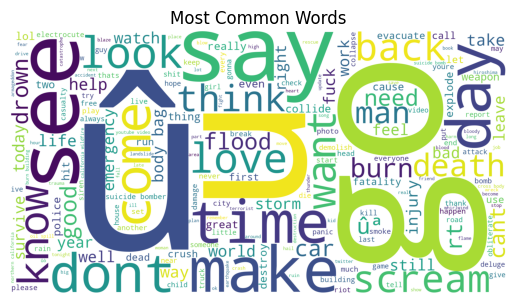

In [81]:
# -------------------------------------------------------------------------------
# 18. WORD CLOUD VISUALIZATION
# -------------------------------------------------------------------------------

# Import required libraries for word cloud
from matplotlib import pyplot as plt
from wordcloud import WordCloud, ImageColorGenerator
import cv2

# Create instance of the WordCloud
word_cloud = WordCloud(height=1080, width=2048, background_color='white')

# Get the text in a big string (assuming you have processed text)
text = " ".join([str(word) for word in trdf["Lemmatized"]])

# Generate the word cloud
word_cloud.generate(text)

# Store the word cloud in a file
word_cloud.to_file('cloud1.png')

# Display the word cloud
plt.imshow(word_cloud)
plt.axis("off")
plt.title("Most Common Words")
plt.show()


In [82]:
# -------------------------------------------------------------------------------
# 19. WORD CLOUD VISUALIZATION IN DESIRED SHAPE
# -------------------------------------------------------------------------------

def create_shaped_wordcloud(text, mask_image_path):
    """
    Create word cloud in a desired shape using a mask image
    """
    # Read a background image and convert to numpy array
    mask_array = np.array(cv2.imread(mask_image_path))
    
    # Create word cloud with mask
    word_cloud = WordCloud(height=1080, width=2048, background_color='white', mask=mask_array)
    
    # Generate the word cloud
    word_cloud.generate(text)
    
    # Optional: Use original image colors to color word cloud
    # image_colors = ImageColorGenerator(mask_array)
    # word_cloud.recolor(color_func=image_colors)
    
    # Save to file
    word_cloud.to_file('shaped_cloud.png')
    
    # Display word cloud
    plt.imshow(word_cloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Most Common Words - Shaped", fontsize=16)
    plt.show()
    
    return word_cloud


In [83]:
# -------------------------------------------------------------------------------
# 20. COMPLETE PREPROCESSING PIPELINE FUNCTION
# -------------------------------------------------------------------------------

def complete_text_preprocessing(text, 
                               remove_punct=True,
                               remove_stopwords_flag=True,
                               remove_frequent_words=True,
                               remove_rare_words=True,
                               apply_stemming=False,
                               apply_lemmatization=True,
                               lemma_with_pos=True,
                               remove_emojis_flag=True,
                               remove_urls_flag=True,
                               remove_html_flag=True,
                               convert_chat_words_flag=True,
                               correct_spelling=False):
    """
    Complete text preprocessing pipeline
    """
    processed_text = text.lower()  # Convert to lowercase
    
    if remove_punct:
        processed_text = processed_text.translate(str.maketrans("", "", string.punctuation))
    
    if remove_stopwords_flag:
        processed_text = remove_stopwords(processed_text)
    
    if remove_urls_flag:
        processed_text = remove_urls(processed_text)
    
    if remove_html_flag:
        processed_text = remove_html(processed_text)
    
    if convert_chat_words_flag:
        processed_text = convert_chat_words(processed_text)
    
    if correct_spelling:
        processed_text = correct_spellings(processed_text)
    
    if apply_lemmatization:
        if lemma_with_pos:
            processed_text = do_lemmatizing_with_POS(processed_text)
        else:
            processed_text = do_lemmatizing(processed_text)
    elif apply_stemming:
        processed_text = do_stemming(processed_text)
    
    return processed_text.strip()

# Example usage:
cleaned_text = complete_text_preprocessing("Your sample text here!")
print(cleaned_text)

sample text
